<a href="https://colab.research.google.com/github/Rafa11-ai/data-science-2024/blob/main/Pertemuan7_Rafa_Hidayah_240401010203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama  : Rafa Hidayah

NIM   : 240401010203

Kelas : IF403

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


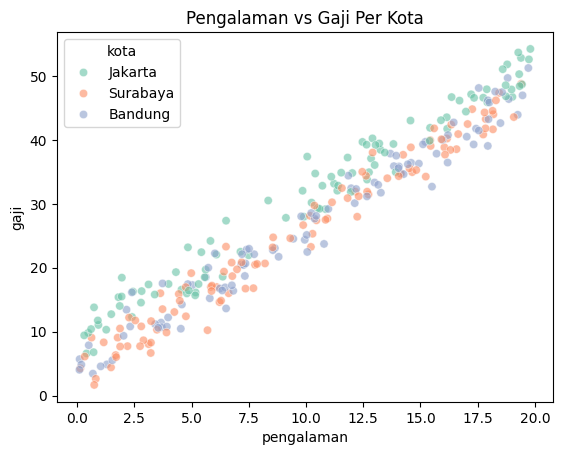

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris
β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292
=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R2   = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.473642


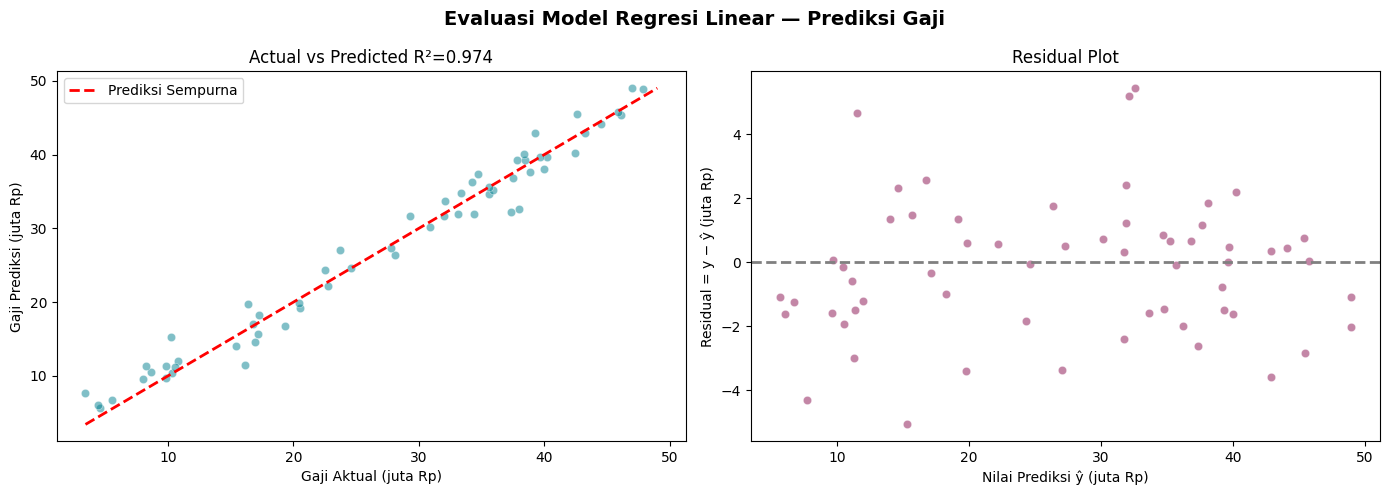

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate & Eksplorasi Dataset
np.random.seed(42);
n=300
pengalaman = np.random.uniform(0,20,n)
edu        = np.random.choice([0,1,2],n)
kota       = np.random.choice(['Jakarta','Surabaya','Bandung'],n)
gaji       = (3.0+2.2*pengalaman+1.5*edu
             + np.where(kota=='Jakarta',4.0,0)
             + np.random.normal(0,2,n))

df = pd.DataFrame({'pengalaman':pengalaman,'edu':edu,'kota':kota,'gaji':gaji})

print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df, x='pengalaman', y='gaji',hue='kota',palette='Set2',alpha=0.6)
plt.title('Pengalaman vs Gaji Per Kota')
plt.show()

# 2. Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(df, columns=['kota'],drop_first=True,dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

X = df.drop('gaji',axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 3. Latih Model & Tampilkan Koefisien
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β₀ (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
    'Fitur'      : X.columns,
    'Koefisien'  : model.coef_.round(3)
}).sort_values('Koefisien',ascending=False)
print(coef_df.to_string(index=False))

# 4. Evaluasi Model
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

y_pred = model.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Calculate RMSE from MSE
r2    = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R2   = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:3f}')

# 5. Visualisasi & Interpretasi
flg, axes =plt.subplots(1,2,figsize=(14,5))

axes[0].scatter(y_test, y_pred, alpha=0.5,
                color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R²={r2:.3f}')
axes[0].legend()
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')
plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

- Actual vs Predicted Plot
  
  What?
  > Gradik Actual vs Predicted membandingkan nilai gaji aktual dengan nilai gaji hasil prediksi model. Garis merah putus-putus menunjukkan kondisi prediksi sempurnak, yaitu ketika nilai prediksi sama dengan nilai aktual.

  So What?
  > Sebagian besar titik berada cukup dekat dengan garis prediksi sempurna. Hal ini menunjukkan bahwa model regresi linear mampu memprediksi gaji dengan baik. Nilai R2 yang tinggi juga menunjukkan bahwa sebagian besar variasi data gaji dapat dijelaskan oleh variabel pengalaman, pendidikan, dan kota.

  Now What?
  > Model dapat digunakan sebagai dasar prediksi gaji pada data baru. Namun, untuk meningkatkan akurasi, dapat ditambahkan variabel lain yang berpengaruh terhadap gaji, seperti usia, jabatan, sertifikasi, atau pengalaman kerja yang lebih spesifik.

- Residual Plot

  What?
  > Residual Plot menampilkan selisih antara nilai aktual dan nilai prediski (residual). Garis horizontal pada nilai 0 menunjukkan kondisi tanpa kesalahan prediksi.

  So What?
  > Titik-titik residual tersebar di sekitar garis 0 tanpa pola tertentu. Hal ini menunjukkan bahwa asumsi linearitas model cukup terpenuhi dan tidak terdapat indikasi kuat adanya bias sistematis dalam prediksi. Variansi residual juga terlihat relatif konstan pada berbagai nilai prediksi.

  Now What?
  > Karena residual tersebar secara acak, model regresi linear sudah cukup sesuai untuk dataset ini.

Apa yang dipelajari

- Pembuatan model regresi untuk memprediksi nilai kontinu.
- Pembagian data training dan testing.
- Evaluasi menggunakan Actual vs Predicted Plot dan Residual Plot.
- Interpretasi hasil model regresi.

Temuan utama

- Model regresi mampu menangkap hubungan antara pengalaman, pendidikan, kota, dan gaji.
- Nilai prediksi cukup dekat dengan nilai aktual.
- Residual tersebar relatif acak di sekitar nol sehingga asumsi linearitas cukup terpenuhi.

Keterbatasan / Pertanyaan
- Masih belajar memahami arti metrik evaluasi seperti R², MAE, dan RMSE.
- Belum sepenuhnya memahami cara membaca Residual Plot secara mendalam.
- Bagaimana cara meningkatkan akurasi model jika hasil prediksi masih kurang sesuai?